# Electric Vehicle Lithium-ion battery dynamic material flow analysis (dMFA)


<img src="../../Images/dMFA_Li_ion_final_dimensions.png" width="800" height="90" alt="MaTrace system definition">


### ODYM model structure
The processes and system variables included are shown in the system definition. We consider the following model aspects for this model:

Time: t, 2000-2023
Age-cohort: c, 2000-2023
Element: e, Li
Unity: 1 (mandatory for all ODYM models but not needed here)
Region: r, USA
Engineering materials: m: Lithium-ion batteries (LIBs) and LIB materials
Good: g, LIBs and other LIB products
Waste_Scrap: w, "LIB scrap" and "other shred"
Scenario: S, BAU 

### Dynamic stock model for the use phase

The Use phase equations remain consistent with those from ODYM Tutorial 6 and are as follows:

Stocks S and outflow O are calculated from apparent final consumption i(t), which is obtained from Circular Energy Storage Online. 

First, we compute the outflow o_c(t,c) of each historic inflow/age-cohort i(c) in year t as

$$o\_c(t,c) = i(c) \cdot sf(t,c) $$

where sf is the survival function of the age cohort, which is 1-cdf (https://en.wikipedia.org/wiki/Survival_function).

The total outflow o(t) in a given year is then

$$ o(t) = \sum_{c\leq t} o\_c(t,c)$$

The mass balance leads to the stock change $dS$:

$$ dS(t) = i(t) - o(t)$$

And the stock finally is computed as

$$ S(t) = \sum_{t'\leq t} ds(t') $$ 

For the system definition above, we have $i=F_{8\_1}$, $o = F_{1\_2}$, and $S = S_{1}$.

### Mass balance equations for the other processes
Unlike ODYM T6, there is no 'scrap loop' to solve for this system. This is because there is no 'inner' loop between processes, 
such as $F_{7\_4}$ in the T6 diagram. Instead all the other processes can be solved using a straightforward mass balance approach, 
where inflow(s) = outflow(s) + net stock change.

The parameters are denoted with the following Greek letters in the model diagram:

$\alpha$ for rates associated with P2, Used battery collection; 

$\lambda$ for rates associated with P4, Used batteries sorting;

$\beta$ for rates associated with P5, Refurbishment;

$\gamma$ for rates associated with P6, Recycling.

For individual rate values, see the equations for each flow in the Mass Balance code chunk and consult the relevant parameter files in the
folder than contains this script.

Mass balance is achieved by using the $ inflows = outflows + net stock change$ equation in addition to 
summing over the relevant model dimensions (using the einsum function) for the outflows and net stock change as required 
to obtain the proper inflow dimensions.

For example, for  $F_{2\_0}$, we use the following equation:

$$ F_{2\_0}(twe)=\sum_{cgm} \alpha (gmw) \cdot F_{1\_2}(tcgme) $$

A similar approach is used for all other mass balance equations. 
See the Mass Balance code chunk for the implementation for each flow.

With these explanations, we can start with the procedure. 
Note that the rest of the text in this file is largely the same as in ODYM Tutorial 6; edits are made only where relevant for this specific system.

## 1) Load ODYM


In [76]:
# Load a local copy of the current ODYM branch:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import openpyxl
import pylab
from copy import deepcopy
import logging as log
from tqdm import tqdm

In [77]:
# add ODYM module directory to system path, relative
MainPath = os.path.join('odym', 'modules')
sys.path.insert(0, MainPath) # add ODYM module directory to system path

# add ODYM module directory to system path, absolute
sys.path.insert(0, os.path.join(os.getcwd(), 'odym', 'modules')) 

# Specify path to dynamic stock model and to datafile, relative
DataPath = os.path.join('docs', 'files')

# Specify path to dynamic stock model and to datafile, absolute
DataPath = os.path.join(os.getcwd(), 'docs', 'Files')

## Path for EV Files. These are for running everything exactly the same as the base Tutorial 6, 
## except that the process and flows reflect the same structure as LIB process and flows except P1 and P2 and related flows
DataPath = os.path.join(os.getcwd(), 'docs', 'Files', 'EV_model')

In [78]:
import ODYM_Classes as msc # import the ODYM class file
import ODYM_Functions as msf # import the ODYM function file
import dynamic_stock_model as dsm # import the dynamic stock model library

# Initialize loggin routine
log_verbosity = eval("log.DEBUG")
log_filename  = 'LogFileTest.md'
[Mylog, console_log, file_log] = msf.function_logger(log_filename, os.getcwd(),
                                                     log_verbosity, log_verbosity)

## 2) Load system classification, index table, and data 
With the model imported, we cannow set up the system definition. The 'classical' elements of the system definition in MFA include: The processes, flows, and stocks, the material, the region, and the time frame studied. Next to these elements, ODYM features/requires the following elements to be specified:
+ The list of chemical elements considered 
+ The classification(s) of the system variables (stocks and flows): Which materials, products, regions, or waste groups are considered? 
+ An index letter to quickly/directly access a model aspect.
+ A dictionary of model parameters.

For all these items ODYM has a specific structure, which are coded in the model config file ODYM_Config_Tutorial6_EV_model_4.xlsx and read using a set of customized functions.

In [79]:
#Read main script parameters
#Load project-specific config file
#ProjectSpecs_ConFile = 'ODYM_Config_Tutorial6LL.xlsx'
ProjectSpecs_ConFile = 'ODYM_Config_Tutorial6_EV_model_4.xlsx'
Model_Configfile     = openpyxl.load_workbook(os.path.join(DataPath, ProjectSpecs_ConFile), data_only=True)
ScriptConfig         = {'Model Setting': Model_Configfile['Config'].cell(4,4).value} # Dictionary with config parameters
Model_Configsheet    = Model_Configfile['Setting_' + ScriptConfig['Model Setting']]

Name_Scenario        = Model_Configsheet.cell(4,4).value
print(Name_Scenario)

#Read control and selection parameters into dictionary
ScriptConfig         = msf.ParseModelControl(Model_Configsheet,ScriptConfig)

Mylog.info('Read and parse config table, including the model index table, from model config sheet.')

INFO (93226576.py <<module>>): Read and parse config table, including the model index table, from model config sheet.


ODYM_Tutorial6_EV_Model_4


In [80]:
(IT_Aspects, IT_Description,IT_Dimension,IT_Classification,IT_Selector,IT_IndexLetter,
PL_Names,PL_Description,PL_Version,PL_IndexStructure,PL_IndexMatch,PL_IndexLayer,
PL_SubFolder,PL_ProxyCode,#PL_ProcMethod,
PL_UpdateOverwrite, PrL_Number, PrL_Name, PrL_Comment, PrL_Type, ScriptConfig) = msf.ParseConfigFile(Model_Configsheet,ScriptConfig,Mylog)

INFO (ODYM_Functions.py <ParseConfigFile>): Read parameter list from model config sheet.
INFO (ODYM_Functions.py <ParseConfigFile>): Read process list from model config sheet.
INFO (ODYM_Functions.py <ParseConfigFile>): Read model run control from model config sheet.
INFO (ODYM_Functions.py <ParseConfigFile>): Read model output control from model config sheet.


In [81]:
class_filename       = 'ODYM_Classifications_EV.xlsx'
Classfile            = openpyxl.load_workbook(os.path.join(DataPath,class_filename), data_only=True)
Classsheet           = Classfile['MAIN_Table']
MasterClassification = msf.ParseClassificationFile_Main(Classsheet,Mylog)

With the code below, the model classifications are created from the info read with msf.ParseClassificationFile_Main.
The index table is created with the info read with msf.ParseConfigFile(Model_Configsheet,ScriptConfig,Mylog) .

In [82]:
Mylog.info('Define model classifications and select items for model classifications according to information provided by config file.')
ModelClassification  = {} # Dict of model classifications
for m in range(0,len(IT_Aspects)):
    ModelClassification[IT_Aspects[m]] = deepcopy(MasterClassification[IT_Classification[m]])
    EvalString = msf.EvalItemSelectString(IT_Selector[m],len(ModelClassification[IT_Aspects[m]].Items))
    if EvalString.find(':') > -1: # range of items is taken
        RangeStart = int(EvalString[0:EvalString.find(':')])
        RangeStop  = int(EvalString[EvalString.find(':')+1::])
        ModelClassification[IT_Aspects[m]].Items = ModelClassification[IT_Aspects[m]].Items[RangeStart:RangeStop]           
    elif EvalString.find('[') > -1: # selected items are taken
        ModelClassification[IT_Aspects[m]].Items = [ModelClassification[IT_Aspects[m]].Items[i] for i in eval(EvalString)]
    elif EvalString == 'all':
        None
    else:
        Mylog.error('Item select error for aspect ' + IT_Aspects[m] + ' were found in datafile.')
        break

# Define model index table and parameter dictionary
Mylog.info('### 2.2 - Define model index table and parameter dictionary')
Model_Time_Start = int(min(ModelClassification['Time'].Items))
Model_Time_End   = int(max(ModelClassification['Time'].Items))
Model_Duration   = Model_Time_End - Model_Time_Start + 1

Mylog.info('Define index table dataframe.')
IndexTable = pd.DataFrame({'Aspect'        : IT_Aspects,  # 'Time' and 'Element' must be present!
                           'Description'   : IT_Description,
                           'Dimension'     : IT_Dimension,
                           'Classification': [ModelClassification[Aspect] for Aspect in IT_Aspects],
                           'IndexLetter'   : IT_IndexLetter})  # Unique one letter (upper or lower case) indices to be used later for calculations.

# Default indexing of IndexTable, other indices are produced on the fly
IndexTable.set_index('Aspect', inplace=True)

# Add indexSize to IndexTable:
IndexTable['IndexSize'] = pd.Series([len(IndexTable.Classification[i].Items) for i in range(0, len(IndexTable.IndexLetter))],
                                    index=IndexTable.index)

# list of the classifications used for each indexletter
IndexTable_ClassificationNames = [IndexTable.Classification[i].Name for i in range(0, len(IndexTable.IndexLetter))]

INFO (3620152477.py <<module>>): Define model classifications and select items for model classifications according to information provided by config file.
INFO (3620152477.py <<module>>): ### 2.2 - Define model index table and parameter dictionary
INFO (3620152477.py <<module>>): Define index table dataframe.
C:\Users\jvend\AppData\Local\Temp\ipykernel_23876\3620152477.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  IndexTable['IndexSize'] = pd.Series([len(IndexTable.Classification[i].Items) for i in range(0, len(IndexTable.IndexLetter))],
C:\Users\jvend\AppData\Local\Temp\ipykernel_23876\3620152477.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a 

That dictionary of classifications enters the index table defined for the system. The index table lists all aspects needed and assigns a classification and index letter to each aspect.

In [83]:
IndexTable

,Description,Dimension,Classification,IndexLetter,IndexSize
Aspect,,,,,
Time,Model time,Time,<ODYM_Classes.Classification object at 0x00000...,t,14
Age-cohort,"Age-cohorts, vintages",Time,<ODYM_Classes.Classification object at 0x00000...,c,14
Element,chemical elements,Element,<ODYM_Classes.Classification object at 0x00000...,e,1
Unity,"trivial classification, 1 entry only",Unity,<ODYM_Classes.Classification object at 0x00000...,1,1
Region,Regions used,Region,<ODYM_Classes.Classification object at 0x00000...,r,1
Engineering materials,Engineering materials considered,Material,<ODYM_Classes.Classification object at 0x00000...,m,2
Good,Goods and products considered,Material,<ODYM_Classes.Classification object at 0x00000...,g,2
Waste_Scrap,waste and scrap types considered,Material,<ODYM_Classes.Classification object at 0x00000...,w,2
Scenario,Scenarios considered,Scenario,<ODYM_Classes.Classification object at 0x00000...,S,2


In [84]:
# Define dimension sizes
Nt = len(IndexTable.Classification[IndexTable.index.get_loc('Time')].Items)
Ne = len(IndexTable.Classification[IndexTable.index.get_loc('Element')].Items)
Nc = len(IndexTable.Classification[IndexTable.index.get_loc('Age-cohort')].Items)
Ng = len(IndexTable.Classification[IndexTable.index.get_loc('Good')].Items)
Nm = len(IndexTable.Classification[IndexTable.index.get_loc('Engineering materials')].Items)
Nw = len(IndexTable.Classification[IndexTable.index.get_loc('Waste_Scrap')].Items)

C:\Users\jvend\AppData\Local\Temp\ipykernel_23876\1070298533.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Nt = len(IndexTable.Classification[IndexTable.index.get_loc('Time')].Items)
C:\Users\jvend\AppData\Local\Temp\ipykernel_23876\1070298533.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Ne = len(IndexTable.Classification[IndexTable.index.get_loc('Element')].Items)
C:\Users\jvend\AppData\Local\Temp\ipykernel_23876\1070298533.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavi

With the index table in place, the model parameters can now be read.

In [85]:
ParameterDict = {}
mo_start = 0 # set mo for re-reading a certain parameter
for mo in range(mo_start,len(PL_Names)):
    #ParPath = os.path.join(os.path.abspath(os.path.join(ProjectSpecs_Path_Main, '.')), 'ODYM_RECC_Database', PL_Version[mo])
    ParPath = os.path.join(DataPath, PL_Names[mo] + '_' + PL_Version[mo])
    Mylog.info('Reading parameter ' + PL_Names[mo])
    # Do not change order of parameters handed over to function!
    MetaData, Values = msf.ReadParameterXLSX(ParPath, PL_Names[mo], PL_IndexStructure[mo], PL_IndexMatch[mo],
                                         PL_IndexLayer[mo],
                                            # PL_ProcMethod[mo], 
                                             MasterClassification, IndexTable,
                                         IndexTable_ClassificationNames, ScriptConfig, Mylog, False)
    ParameterDict[PL_Names[mo]] = msc.Parameter(Name=MetaData['Dataset_Name'], ID=MetaData['Dataset_ID'],
                                                UUID=MetaData['Dataset_UUID'], P_Res=None, MetaData=MetaData,
                                                Indices=PL_IndexStructure[mo], Values=Values, Uncert=None,
                                                Unit=MetaData['Dataset_Unit'])
    Mylog.info('Current parameter file UUID: ' + MetaData['Dataset_UUID'])
    Mylog.info('_')
Mylog.info('Reading of parameters finished.')

INFO (3989882953.py <<module>>): Reading parameter ODYM_T6_LifetimeEV
INFO (ODYM_Functions.py <ReadParameterXLSX>): LIST
INFO (ODYM_Functions.py <ReadParameterXLSX>): A total of 2 values was read from file for parameter ODYM_T6_LifetimeEV.
INFO (ODYM_Functions.py <ReadParameterXLSX>): 2.0 of 2 values for parameter ODYM_T6_LifetimeEV were assigned.
INFO (3989882953.py <<module>>): Current parameter file UUID: 1ad185e8-af42-4ee1-8cc5-2215081de35c
INFO (3989882953.py <<module>>): _
INFO (3989882953.py <<module>>): Reading parameter ODYM_T6_EVConsumption
INFO (ODYM_Functions.py <ReadParameterXLSX>): TABLE
INFO (ODYM_Functions.py <ReadParameterXLSX>): A total of 3208 values was read from file for parameter ODYM_T6_EVConsumption.
INFO (ODYM_Functions.py <ReadParameterXLSX>): 56.0 of 112 values for parameter ODYM_T6_EVConsumption were assigned.
INFO (3989882953.py <<module>>): Current parameter file UUID: 6738f872-8ec9-4ba5-986b-6da947f03289
INFO (3989882953.py <<module>>): _
INFO (3989882953

In [86]:
PL_Names

['ODYM_T6_LifetimeEV',
 'ODYM_T6_EVConsumption',
 'ODYM_T6_ToSortingRate',
 'ODYM_T6_ToUsedExportRate',
 'ODYM_T6_ToLandfillRate',
 'ODYM_T6_SortingToRefurbishmentRate',
 'ODYM_T6_SortingToRecyclingRate',
 'ODYM_T6_RefurbishmentSectorSplit',
 'ODYM_T6_RecyclingToBlackMassExport',
 'ODYM_T6_RecyclingToOtherProduction',
 'ODYM_T6_RecyclingToRecycledMaterialExport',
 'ODYM_T6_RecyclingToDomesticProduction',
 'ODYM_T6_RecycledProductsYieldLoss']

Print some core data elements for info:

In [87]:
ScriptConfig

{'Model Setting': 'Tutorial6',
 'Name of model setting': 'ODYM_Tutorial6_EV_Model_4',
 'Description': 'Scenario analysis of dispersion of EV LIBs.',
 'Name of model script used': 'ODYM_Tutorial_6_MaTrace',
 'Version of master classification': 'ODYM_Classifications_EV',
 'Version of ODYM Classes': 'V01',
 'Version of ODYM Functions': 'V01',
 'Logging_Verbosity': 'DEBUG'}

In [88]:
PrL_Name

['Environment',
 'Use phase',
 'Used battery collection',
 'Landfill',
 'Used battery sorting',
 'Refurbishment',
 'Recycling',
 'Production from recycled material',
 'Sales and distribution']

We can now define our MFA system: 

## 3) Define MFA system
This system has a name, a geographical scope, a system-wide unit, a time frame, an index table with all aspects defined, and a list of chemical elements considered.


In [89]:
MaTrace_System = msc.MFAsystem(Name = 'MaTrace_LIBEV_US', 
                      Geogr_Scope = 'USA', 
                      Unit = 'Mt', 
                      ProcessList = [], 
                      FlowDict = {}, 
                      StockDict = {},
                      ParameterDict = ParameterDict, 
                      Time_Start = Model_Time_Start, 
                      Time_End = Model_Time_End, 
                      IndexTable = IndexTable, 
                      Elements = IndexTable.loc['Element'].Classification.Items) # Initialize MFA system

# Add processes to system
for m in range(0, len(PrL_Number)):
    MaTrace_System.ProcessList.append(msc.Process(Name = PrL_Name[m], ID   = PrL_Number[m]))

In [90]:
# FLOW DEFINITION CHUNK 

# Define the flows of the system, and initialise their values:
# Flow_value_index = 0
MaTrace_System.FlowDict['F_0_8'] = msc.Flow(Name = 'Exogenous final consumption of EV LIBs', P_Start = 0, P_End = 8,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 1
MaTrace_System.FlowDict['F_8_1'] = msc.Flow(Name = 'Battery sales (consumption)', P_Start = 8, P_End = 1,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 2
MaTrace_System.FlowDict['F_1_2'] = msc.Flow(Name = 'Used batteries to collection', P_Start = 1, P_End = 2,
                                            Indices = 't,c,g,m,e', Values=None)
# Flow_value_index = 3
MaTrace_System.FlowDict['F_2_0'] = msc.Flow(Name = 'Exported batteries (used)', P_Start = 2, P_End = 0,
                                            Indices = 't,w,e', Values=None) 
# Flow_value_index = 4
MaTrace_System.FlowDict['F_2_3'] = msc.Flow(Name = 'Used batteries to landfill', P_Start = 2, P_End = 3,
                                            Indices = 't,e', Values=None) 
# Flow_value_index = 5
MaTrace_System.FlowDict['F_2_4'] = msc.Flow(Name = 'Used batteries to sorting', P_Start = 2, P_End = 4,
                                            Indices = 't,w,e', Values=None)
# Flow_value_index = 6
MaTrace_System.FlowDict['F_4_0'] = msc.Flow(Name = 'Sorting loss', P_Start = 4, P_End = 0,
                                            Indices = 't,e', Values=None)
# Flow_value_index = 7
MaTrace_System.FlowDict['F_4_5'] = msc.Flow(Name = 'Sorted batteries to refurbishment', P_Start = 4, P_End = 5,
                                            Indices = 't,m,e', Values=None)
# Flow_value_index = 8
MaTrace_System.FlowDict['F_4_6'] = msc.Flow(Name = 'Sorted batteries to recycling', P_Start = 4, P_End = 6,
                                            Indices = 't,m,e', Values=None)
# Flow_value_index = 9
MaTrace_System.FlowDict['F_5_8'] = msc.Flow(Name = 'Refurbishment to sales', P_Start = 5, P_End = 8,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 10
MaTrace_System.FlowDict['F_6_01'] = msc.Flow(Name = 'Recycled material exported black mass', P_Start = 6, P_End = 0,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 11
MaTrace_System.FlowDict['F_6_02'] = msc.Flow(Name = 'Recycled material to other (non LIB) production', P_Start = 6, P_End = 0,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 12
MaTrace_System.FlowDict['F_6_03'] = msc.Flow(Name = 'Recycled material to export', P_Start = 6, P_End = 0,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 10 #Old
# Flow_value_index = 13
MaTrace_System.FlowDict['F_6_7'] = msc.Flow(Name = 'Recycled material for domestic battery production', P_Start = 6, P_End = 7,
                                            Indices = 't,g,m,e', Values=None)
# Flow_value_index = 14 
MaTrace_System.FlowDict['F_7_8'] = msc.Flow(Name = 'Recycled battery production', P_Start = 7, P_End = 8,
                                            Indices = 't,g,m,e', Values=None)

# Stocks

MaTrace_System.StockDict['S_1']   = msc.Stock(Name = 'EV in-use stock', P_Res = 1, Type = 0,
                                              Indices = 't,c,g,m,e', Values=None)

MaTrace_System.StockDict['dS_1']  = msc.Stock(Name = 'EV in-use stock change', P_Res = 1, Type = 1,
                                              Indices = 't,g,m,e', Values=None)

MaTrace_System.StockDict['S_3']   = msc.Stock(Name = 'landfill stock', P_Res = 3, Type = 0,
                                              Indices = 't,e', Values=None) #TODO: revise indeces included - need w?

MaTrace_System.StockDict['dS_3']  = msc.Stock(Name = 'landfill stock change', P_Res = 3, Type = 1,
                                              Indices = 't,e', Values=None) #TODO: revise indeces included - need w?


MaTrace_System.Initialize_FlowValues()  # Assign empty arrays to flows according to dimensions.
MaTrace_System.Initialize_StockValues() # Assign empty arrays to flows according to dimensions.

In [91]:
# Check whether flow value arrays match their indices, etc. See method documentation.
MaTrace_System.Consistency_Check() 

(True, True, True)

Above you see that all system variables (stocks and flows) have time and element as their aspects, which is a requirement, but that other aspects (good g, material m, waste w) are assigned in a flexible manner in line with the system definition.

## 4) Programming a solution of the MFA system
Now the system definition is complete, and we can program the model solution, making use of the dynamic_stock_model methods (see also https://github.com/stefanpauliuk/dynamic_stock_model) and a matrix equation.

The solution is calculated year-by-year, as for each year, the scrap and recycling flows need to be determined and then the recycling flows are re-inserted as final consumption into the use phase.

Simplification: To make an easy year-by-year calculation possible, it is assumed that the outflow from the use phase in the same year as the consumption happened is zero. In other words, the discrete lifetime distribution for scrapping at age 0 is chosen or set to zero: $$ pdf(0) = 0; SF(0) =1 $$.

In [92]:
# ScenarioSelect to assign the scenario-specific values to the system variables
ScSe = 0

In [93]:
# Creating a matrix for the lifetime std dev for each good.
lifetime_sd = np.array([[5.0, 5.0]])

In [94]:
# 1) Pre-calculate survival tables to reduce computation time
# Creating a matrix for the lifetime std dev for each good.
lifetime_sd = np.array([[5.0, 5.0]])
SF_Array = np.zeros((Nc,Nc,Ng)) # survival functions, by year, age-cohort, and good. 
# PDFs are stored externally because recreating them with scipy.stats is slow.
# Build pdf array from lifetime distribution: Probability of survival.
for g in tqdm(range(0, Ng), unit = ' sectors',leave = True, position = 0):
    lt = {'Type'  : 'Normal',
          'Mean'  : [MaTrace_System.ParameterDict['ODYM_T6_LifetimeEV'].Values[g]],
          'StdDev': [lifetime_sd[0, g]]}
    SF_Array[:, :, g] = dsm.DynamicStockModel(t = np.arange(0, Nc, 1), lt = lt).compute_sf().copy()
    np.fill_diagonal(SF_Array[:, :, g],1) # no outflows from current year, this would break the mass balance in the calculation routine below, as the element composition of the current year is not yet known.
    # Those parts of the stock remain in use instead.


100%|██████████| 2/2 [00:00<00:00, 1420.59 sectors/s]


In [95]:
# This chunk is for initializing variables to store flow and stock values by year

flow_values = np.zeros( (Nt, len(list(MaTrace_System.FlowDict.keys())), Ng), dtype = float) #dims: time, flows, goods
flow_keys = list(MaTrace_System.FlowDict.keys())
flow_names = list()

for i, key in enumerate(flow_keys):
    flow_names.insert(i, MaTrace_System.FlowDict[key].Name)


stock_values = np.zeros( (Nt, len(list(MaTrace_System.StockDict.keys())), Ng), dtype = float)#dims: time, stocks, goods
stock_keys = list(MaTrace_System.StockDict.keys())

stock_names = list()

for i, key in enumerate(stock_keys):
    stock_names.insert(i, MaTrace_System.StockDict[key].Name)

In [96]:
# MASS BALANCE EQUATIONS CHUNK

# 2) Define the material-element composition of products to convert from 
# product level (dynamic stock model) to the material and element level.
Par_Material_Element_Composition_Products = np.zeros((Nc,Ng,Nm,Ne))

# 3) Assign single inflow and convert to system unit.
# F_0_8.Values dim are t = 14, g = 2, me = 12 = 2 ,  (time, goods, material, element) 
# EVConsumption.Values are dim S = 2, t = 14, g = 2, m = 2 (Scenario, time, goods, material)
# Original function call for T6 file only gets value at t = 0 for F_0_8, so changed it to get values for all t.

# Function call that adds all time values to the F_0_8 flow. Multiply by 1000 to change from kilotons to tons (metric)
MaTrace_System.FlowDict['F_0_8'].Values[:,0,:,0]  = MaTrace_System.ParameterDict['ODYM_T6_EVConsumption'].Values[ScSe,:,0,:]*1000

# Loop over all years until end of model time
for t in tqdm(range(0,Nt), unit = ' Year', leave = True, position = 0):
    print("Year: ", t)

    # 4) Compute the solution of the MaTrace model to map the flow of materials from EoL products to recycled material in new goods 
    # for final consumption.
    # (in the first year 0, the flow is 0).
    
    # a) Postconsumer scrap - Flows associated with Used battery collection process
    # Parameters associated with this process (e.g., ToSortingRate) are denoted using alpha in the flow diagram. 

    # F_2_4 - Used batteries to sorting.
    # Dimensions: F_2_4: t,w,e. Rate: S,g,m,w. F_1_2: t,c,g,m,e
    MaTrace_System.FlowDict['F_2_4'].Values[t,:,:] = np.einsum('gmw,cgme->we', \
        MaTrace_System.ParameterDict['ODYM_T6_ToSortingRate'].Values[ScSe,:,:,:],
        MaTrace_System.FlowDict['F_1_2'].Values[t,:,:,:,:])

    # F_2_0 - Exported batteries (used). Added equation for this flow based on relevant rate.  
    # Dimensions: F_2_0: t,w,e. Export Rate: S,g,m,w. F_1_2: t,c,g,m,e
    MaTrace_System.FlowDict['F_2_0'].Values[t,:] = np.einsum('gmw,cgme->we', \
        MaTrace_System.ParameterDict['ODYM_T6_ToUsedExportRate'].Values[ScSe,:,:,:],\
        MaTrace_System.FlowDict['F_1_2'].Values[t,:,:,:,:]) 
    
    # F_2_3, to landfill flow. Calculated as inflow to P2 minus other outlfows from P2.
    # Dimensions: F_2_3: t,e.  F_1_2: t,c,g,m,e. F_2_0: t,w,e. F_2_4: t,w,e.
    MaTrace_System.FlowDict['F_2_3'].Values[t,:]     = np.einsum('cgme->e',MaTrace_System.FlowDict['F_1_2'].Values[t,:,:,:,:]) -\
                      np.einsum('we->e',MaTrace_System.FlowDict['F_2_0'].Values[t,:,:]) -\
                      np.einsum('we->e',MaTrace_System.FlowDict['F_2_4'].Values[t,:,:])

    # dS3 = change in S_3, landfill stock, is the same as the input flow into the stock
    MaTrace_System.StockDict['dS_3'].Values[t,:] = MaTrace_System.FlowDict['F_2_3'].Values[t,:] 

    # Total landfill stock is the same as previous year's landfill stock plus this year's dS flow
    if t == 0:
        MaTrace_System.StockDict['S_3'].Values[t,:] = 0 # the : in [t,:] should represent the e dimension
    else:
        MaTrace_System.StockDict['S_3'].Values[t,:] = MaTrace_System.StockDict['S_3'].Values[t-1,:] + MaTrace_System.StockDict['dS_3'].Values[t,:] 
    # End of flows related to used battery collection process  


      
    # b) Solve the 'scrap loop' in accordance with the equations listed above.
    # Removed all the scrap loop equations related to part b of original T6 file as there is no scrap loop to solve in this sytem.
    # See explanation in the description at the beginning of this file.

    # c) calculate remaining flows from model parameters:
    # Sorting process. 
    # Parameters associated with this process (e.g., ToRefurbishmentRate) are denoted using 'lambda' in the flow diagram. 
    MaTrace_System.FlowDict['F_4_5'].Values[t,:,:]   = np.einsum('wm,we->me',MaTrace_System.ParameterDict['ODYM_T6_SortingToRefurbishmentRate'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_2_4'].Values[t,:,:])
    MaTrace_System.FlowDict['F_4_6'].Values[t,:,:]   = np.einsum('wm,we->me',MaTrace_System.ParameterDict['ODYM_T6_SortingToRecyclingRate'].Values[ScSe,:,:], MaTrace_System.FlowDict['F_2_4'].Values[t,:,:])

    # Refurbishment process
    # Parameters associated with this process (e.g., SectorSplit) are denoted using 'beta' in the flow diagram. 
    # JV: Input file assumes all refurbished material goes to EV LIBs good (good #0).
    MaTrace_System.FlowDict['F_5_8'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RefurbishmentSectorSplit'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_5'].Values[t,:,:])

    # Recycling process
    # Parameters associated with this process (e.g., ToBlackMassExport) are denoted using 'gamma' in the flow diagram. 
    
    # F_6_01, exported black mass flow. 
    # Dimensions: F_6_01: t,g,m,e. Black mass export rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_01'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToBlackMassExport'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])

    # F_6_02, other production (non LIB) flow. 
    # Dimensions: F_6_02: t,g,m,e. Recycled material to other production rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_02'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToOtherProduction'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])
    
    # F_6_03, recycled material to export flow. 
    # Dimensions: F_6_03: t,g,m,e. Recycled material to export rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_03'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToRecycledMaterialExport'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])
 
    # F_6_7, recycled material to domestic LIB flow. 
    # Unlike F2_3, can't be calculated as flow into P6 - other flows out of P6.
    # This is because we need to add the g variable to F_6_7, which is not present in input flow F_4_6
    # Thus we do a check after this flow to make sure that [e] dimension of F_6_01 + F_6_02 + F_6_03 + F_6_7 = 1
    
    # Dimensions: F_6_7: t,g,m,e. Recycled material to domestic production rate: m,g.  F_4_6: t,m,e. 
    MaTrace_System.FlowDict['F_6_7'].Values[t,:,:,:] = np.einsum('mg,me->gme',MaTrace_System.ParameterDict['ODYM_T6_RecyclingToDomesticProduction'].Values[ScSe,:,:],MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])

    # P6 Check dimensions: g,m,e
    P_6_Check =  MaTrace_System.FlowDict['F_6_01'].Values[t,:,:,:] +  MaTrace_System.FlowDict['F_6_02'].Values[t,:,:,:] +  MaTrace_System.FlowDict['F_6_03'].Values[t,:,:,:] + MaTrace_System.FlowDict['F_6_7'].Values[t,:,:,:]

    if np.sum(P_6_Check[:,:,0]) != np.sum(MaTrace_System.FlowDict['F_4_6'].Values[t,:,0]):
        print("P6 flows not balanced")
    
    # d) finally, use the mass balance to compute the outflows:

    # Sorting process loss
    # F_4_0. Computed as F_2_4 - F_4_5 - F_4_6
    MaTrace_System.FlowDict['F_4_0'].Values[t,:]     = np.einsum('we->e',MaTrace_System.FlowDict['F_2_4'].Values[t,:,:]) -\
                      np.einsum('me->e',MaTrace_System.FlowDict['F_4_5'].Values[t,:,:]) -\
                      np.einsum('me->e',MaTrace_System.FlowDict['F_4_6'].Values[t,:,:])

    # Production from recycled material process. Assumes no loss for BAU scenario.
    FabYield = 1 - np.einsum('gmw->gm',MaTrace_System.ParameterDict['ODYM_T6_RecycledProductsYieldLoss'].Values[ScSe,:,:,:])
    MaTrace_System.FlowDict['F_7_8'].Values[t,:,:,:] = np.einsum('gme,gm->gme',MaTrace_System.FlowDict['F_6_7'].Values[t,:,:,:],\
                      FabYield)        
    
    # Exogenous flow correction
    # Since our exogenous final consumption value includes the recycled and refurbished flows, we need to remove them from that value 
    # before adding them back in step 5. However, we only need to remove inflows of the main good, EV LIBs (g index == 0), 
    # as the exogenous input for other LIB products (g index == 1) is 0 for all t.
    if t != 0:
        MaTrace_System.FlowDict['F_0_8'].Values[t,0,:,:] = MaTrace_System.FlowDict['F_0_8'].Values[t,0,:,:] - MaTrace_System.FlowDict['F_7_8'].Values[t-1,0,:,:] - MaTrace_System.FlowDict['F_5_8'].Values[t-1,0,:,:] 

    # 5) Add exogenous final consumption to recycled and refurbished product flows:
    MaTrace_System.FlowDict['F_8_1'].Values[t,:,:,:] = MaTrace_System.FlowDict['F_7_8'].Values[t,:,:,:] + MaTrace_System.FlowDict['F_5_8'].Values[t,:,:,:] + MaTrace_System.FlowDict['F_0_8'].Values[t,:,:,:]
    
    # 6) Calculate the material-element composition of products for current age-cohort
    for g in range(0,Ng):
        if MaTrace_System.FlowDict['F_8_1'].Values[t,g,:,:].sum() != 0:
            Par_Material_Element_Composition_Products[t,g,:,:] = MaTrace_System.FlowDict['F_8_1'].Values[t,g,:,:] / MaTrace_System.FlowDict['F_8_1'].Values[t,g,:,:].sum()
        
    # 7) Define and solve dynamic stock model to calculate next year's outflow
    # Create helper DSM for computing the dynamic stock model:
    # Here, the mass of the product g is its total mass.
    # A normal (Gaussian) lifetime distribution is assumed.
    for g in range(0,Ng):
         
        DSM_MaTrace = dsm.DynamicStockModel(t = np.arange(0, Nt, 1),
                                            i = np.einsum('tme->t',MaTrace_System.FlowDict['F_8_1'].Values[:,g,:,:]), 
                                           lt = {'Type': 'Normal', 
                                                 'Mean': [MaTrace_System.ParameterDict['ODYM_T6_LifetimeEV'].Values[g]],
                                                 'StdDev': [lifetime_sd[0, g]]})
 
        # Here, the lt attribute is not used, instead, we assign the pre-calculated SF array:
        DSM_MaTrace.sf  = SF_Array[:,:,g]
    
        Stock_by_cohort = DSM_MaTrace.compute_s_c_inflow_driven()
        O_C             = DSM_MaTrace.compute_o_c_from_s_c()
        S               = DSM_MaTrace.compute_stock_total()
        DS              = DSM_MaTrace.compute_stock_change()
        DS_C            = np.zeros(Stock_by_cohort.shape)
        DS_C[0,:]       = Stock_by_cohort[0,:]
        DS_C[1::,:]     = np.diff(Stock_by_cohort,axis=0)

        O               = DSM_MaTrace.compute_outflow_total() # outflow total rather than by cohort for value checks
        
        # Print statements added for value checks
        print("g at index: ", g,"; name: ", IndexTable.Classification[IndexTable.index.get_loc('Good')].Items[g])
        print("i at t = ",t," : ", np.einsum('tme->t',MaTrace_System.FlowDict['F_8_1'].Values[:,g,:,:])[t])
        print("Stock by cohort at t = ",t,": ", Stock_by_cohort[t])
        print("O_C at t = ",t,": ", O_C[t])
        print("O: ", O, "\n")
        
        # 8) Map flows and stocks at goods level g to materials and elements:
        MaTrace_System.FlowDict['F_1_2'].Values[:,:,g,:,:] = np.einsum('tc,cme->tcme',O_C,            Par_Material_Element_Composition_Products[:,g,:,:]).copy()
        MaTrace_System.StockDict[ 'S_1'].Values[:,:,g,:,:] = np.einsum('tc,cme->tcme',Stock_by_cohort,Par_Material_Element_Composition_Products[:,g,:,:]).copy()
        MaTrace_System.StockDict['dS_1'].Values[:,g,:,:]   = np.einsum('tc,cme->tme', DS_C,           Par_Material_Element_Composition_Products[:,g,:,:]).copy()

        # Here we store flow and stock values in DFs for inspection and printing results tables
        #TODO: Consider moving flows that don't have G dimesion to Stock IF Statement. Doesn't affect results as this 
        # is only storing values and does not interact with the flow/stocks calculations.
        getFlowVals = list(MaTrace_System.FlowDict.values())
        flow_values[t,0,g] =  getFlowVals[0].Values[t,g,0,0]                # Flow_0_8, Indices = 't,g,m,e'
        flow_values[t,1,g] =  getFlowVals[1].Values[t,g,0,0]                # Flow_8_1, Indices = 't,g,m,e'
        flow_values[t,2,g] =  np.sum(getFlowVals[2].Values[t,:,g,0,0])      # Flow_1_2, Indices = 't,c,g,m,e'
        flow_values[t,3,g] =  getFlowVals[3].Values[t,0,0]                  # Flow_2_0, Indices = 't,w,e'
        flow_values[t,4,g] =  getFlowVals[4].Values[t,0]                    # Flow_2_3, Indices = 't,e'
        flow_values[t,5,g] =  getFlowVals[5].Values[t,0,0]                  # Flow_2_4, Indices = 't,w,e'
        flow_values[t,6,g] =  getFlowVals[6].Values[t,0]                    # Flow_4_0, Indices = 't,e'
        flow_values[t,7,g] =  getFlowVals[7].Values[t,0,0]                  # Flow_4_5, Indices = 't,m,e'
        flow_values[t,8,g] =  getFlowVals[8].Values[t,0,0]                  # Flow_4_6, Indices = 't,e'
        flow_values[t,9,g] =  getFlowVals[9].Values[t,g,0,0]                # Flow_5_8, Indices = 't,g,m,e'
        flow_values[t,10,g] = getFlowVals[10].Values[t,g,0,0]               # Flow_6_01, Indices = 't,g,m,e'
        flow_values[t,11,g] = getFlowVals[11].Values[t,g,0,0]               # Flow_6_02, Indices = 't,g,m,e'
        flow_values[t,12,g] = getFlowVals[12].Values[t,g,0,0]               # Flow_6_03, Indices = 't,g,m,e'
        flow_values[t,13,g] = getFlowVals[13].Values[t,g,0,0]               # Flow_6_7, Indices = 't,g,m,e'
        flow_values[t,14,g] = getFlowVals[14].Values[t,g,0,0]               # Flow_7_8, Indices = 't,g,m,e'
        
        getStockVals = list(MaTrace_System.StockDict.values())
        stock_values[t,0,g] = np.sum(getStockVals[0].Values[t,:,g,0,0])     # Stock S_1, Indices = 't,c,g,m,e'
        stock_values[t,1,g] = getStockVals[1].Values[t,g,0,0]               # Stock dS_1, Indices = 't,g,m,e'

        # Since landfill stock does not differentiate by good, assign all stock to good # 0
        if(g == 0):
            stock_values[t,2,g] = getStockVals[2].Values[t,0]               # Stock S_3, Indices = 't,e'
            stock_values[t,3,g] = getStockVals[3].Values[t,0]               # Stock dS_3, Indices = 't,e'
        else:
            stock_values[t,2,g] = 0                                         # Stock S_3, Indices = 't,e'
            stock_values[t,3,g] = 0                                         # Stock dS_3, Indices = 't,e'

        # End of DSM for loop



        # NOTE: The computation above is still quite inefficient as many redundant results are generated. 
        # If speed is an issue, e.g., for MC simulations, the code can be sped up by customizing the dynamic stock model functions to the case at hand
        # or directly programming the solution using np.einsum('...',Inflow,SurvivalTable)
        # Here, the dynamic stock model library was used because its methods are tested.



  0%|          | 0/14 [00:00<?, ? Year/s]C:\Users\jvend\AppData\Local\Temp\ipykernel_23876\3898525136.py:154: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("g at index: ", g,"; name: ", IndexTable.Classification[IndexTable.index.get_loc('Good')].Items[g])
100%|██████████| 14/14 [00:00<00:00, 982.22 Year/s]

Year:  0
g at index:  0 ; name:  EV LIB
i at t =  0  :  173.0
Stock by cohort at t =  0 :  [173.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
O_C at t =  0 :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
O:  [ 0.          2.40529642  1.53047641  2.28017238  3.26433226  4.49062458
  5.9361509   7.54030598  9.20362502 10.79480542 12.16624933 13.17603157
 13.71192973 13.71192973] 

g at index:  1 ; name:  other EV LIB products
i at t =  0  :  0.0
Stock by cohort at t =  0 :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
O_C at t =  0 :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
O:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] 

Year:  1
P6 flows not balanced
g at index:  0 ; name:  EV LIB
i at t =  1  :  2548.557910491127
Stock by cohort at t =  1 :  [ 170.59470358 2548.55791049    0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.        ]
O_C at t =  1 :  [ 2.40529642  0.      

In [97]:
# RECORD RESULTS IN DFs CHUNK
# Store flow and stock values in a list of length Ng to easily inspect values by time step 
# Create empty lists to hold flows and stocks values by good
flow_values_by_g = [None] * Ng
stock_values_by_g = [None] * Ng

for g in range(0,Ng):
    # Add flow values to list by good, as data frame
    flow_values_by_g[g] = pd.DataFrame(data = flow_values[:,:,g])
    flow_values_by_g[g] = flow_values_by_g[g].reset_index() #Add index as first column of dataframe

    # Add flow keys and names as first element in each column of data frame
    flow_key_rows= pd.DataFrame(flow_keys) 
    flow_key_rows = flow_key_rows.T
    
    flow_name_rows= pd.DataFrame(flow_names) 
    flow_name_rows = flow_name_rows.T
    
    flow_values_by_g[g] = pd.concat([flow_key_rows, flow_name_rows, flow_values_by_g[g]], ignore_index = True) # add row

    # Repeat for stocks
    stock_values_by_g[g] = pd.DataFrame(data = stock_values[:,:,g])
    stock_values_by_g[g] = stock_values_by_g[g].reset_index() #Add index as first column of dataframe

    # Add stock keys and names as first element in each column of data frame
    stock_key_rows= pd.DataFrame(stock_keys) 
    stock_key_rows = stock_key_rows.T
    
    stock_name_rows= pd.DataFrame(stock_names) 
    stock_name_rows = stock_name_rows.T
    
    stock_values_by_g[g] = pd.concat([stock_key_rows, stock_name_rows, stock_values_by_g[g]], ignore_index = True) # add row


## 5) Mass-balance-check
One major advantage of the ODYM system structure is that mass balance checks can be performed automatically using unit-tested routines without further programming need:

In [98]:
Bal = MaTrace_System.MassBalance()
print(Bal.shape) # dimensions of balance are: time step x process x chemical element
print(np.abs(Bal).sum(axis = 0)) # reports the sum of all absolute balancing errors by process.

(14, 9, 1)
[[1.22716948e-10]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.81377136e-12]
 [0.00000000e+00]
 [7.53674900e-13]
 [0.00000000e+00]
 [4.05349643e-11]]


The ODYM mass balance array reports the balance for each chemical element, each year, and each process, including the system balance (process 0).

The result shows that both the system processes and the system as a whole are balanced.

## 6) Results
Plot the LIB stock over time:

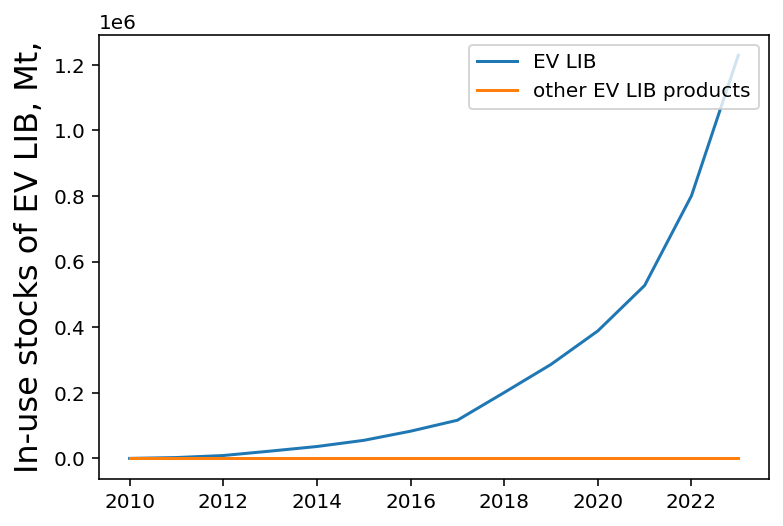

In [99]:
# Plot In-Use stock
MyColorCycle = pylab.cm.Paired(np.arange(0,1,0.1)) # select 10 colors from the 'Paired' color map.
fig, ax = plt.subplots()
ax.plot(MaTrace_System.IndexTable['Classification']['Time'].Items, 
            np.einsum('tcgme->tg',MaTrace_System.StockDict[ 'S_1'].Values)) 
ax.set_ylabel('In-use stocks of EV LIB, Mt,',fontsize =16)
ax.legend(MaTrace_System.IndexTable['Classification']['Good'].Items, loc='upper right',prop={'size':10})

Text(0, 0.5, 'Landfill stocks of LIBs, Mt,')

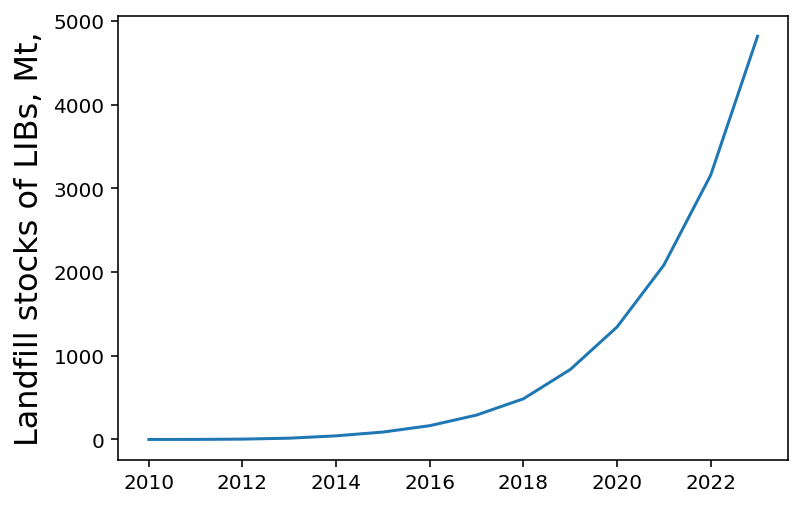

In [100]:
# Plot LF stock
MyColorCycle = pylab.cm.Paired(np.arange(0,1,0.1)) # select 10 colors from the 'Paired' color map.
fig, ax = plt.subplots()
ax.plot(MaTrace_System.IndexTable['Classification']['Time'].Items, 
            MaTrace_System.StockDict[ 'S_3'].Values) 
ax.set_ylabel('Landfill stocks of LIBs, Mt,',fontsize =16)

Chart 1: LIB in-use stocks rise rapidly as new LIB exogenous inflow is added to the system, and the relatively long in-use phase (determined by the lifetime distribution parameters) are not reach EOL, so the LIB in-use stock builds up quickly. All material is used for LIBs rather than other LIB products, as materials not related to LIBs leave the system.

Chart 2: LIB Landfill stocks rise much less quickly than in use stocks. This is due to small mass of batteries reaching EOL compared to the mass of batteries entering the system each year.

In [101]:
# Print LIB flow values
display(flow_values_by_g[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,index
0,F_0_8,F_8_1,F_1_2,F_2_0,F_2_3,F_2_4,F_4_0,F_4_5,F_4_6,F_5_8,F_6_01,F_6_02,F_6_03,F_6_7,F_7_8,NaN
1,Exogenous final consumption of EV LIBs,Battery sales (consumption),Used batteries to collection,Exported batteries (used),Used batteries to landfill,Used batteries to sorting,Sorting loss,Sorted batteries to refurbishment,Sorted batteries to recycling,Refurbishment to sales,Recycled material exported black mass,Recycled material to other (non LIB) production,Recycled material to export,Recycled material for domestic battery production,Recycled battery production,NaN
2,173.0,173.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2547.0,2548.55791,2.405296,0.120265,0.24053,2.044502,-0.0,1.349371,0.695131,1.349371,0.0,0.0,0.0,0.208539,0.208539,1.0
4,6181.44209,6205.383813,36.964218,1.848211,3.696422,31.419585,-0.0,20.736926,10.682659,20.736926,0.0,0.0,0.0,3.204798,3.204798,2.0
5,13445.058276,13517.019487,111.102688,5.555134,11.110269,94.437285,-0.0,62.328608,32.108677,62.328608,0.0,0.0,0.0,9.632603,9.632603,3.0
6,14171.038789,14352.190793,279.685046,13.984252,27.968505,237.732289,-0.0,156.903311,80.828978,156.903311,0.0,0.0,0.0,24.248693,24.248693,4.0
7,18924.847996,19218.57551,453.493151,22.674658,45.349315,385.469179,-0.0,254.409658,131.059521,254.409658,0.0,0.0,0.0,39.317856,39.317856,5.0
8,28184.272486,28677.502401,761.509828,38.075491,76.150983,647.283354,-0.0,427.207013,220.07634,427.207013,0.0,0.0,0.0,66.022902,66.022902,6.0
9,33836.770084,34658.713097,1269.018083,63.450904,126.901808,1078.665371,0.0,711.919145,366.746226,711.919145,0.0,0.0,0.0,110.023868,110.023868,7.0


In [102]:
# Print LIB stock values
display(stock_values_by_g[0])

,0,1,2,3,index
0,S_1,dS_1,S_3,dS_3,NaN
1,EV in-use stock,EV in-use stock change,landfill stock,landfill stock change,NaN
2,173.0,173.0,0.0,0.0,0.0
3,2719.152614,2546.152614,0.24053,0.24053,1.0
4,8887.57221,6168.419596,3.936951,3.696422,2.0
5,22293.489009,13405.916799,15.04722,11.110269,3.0
6,36365.994756,14072.505747,43.015725,27.968505,4.0
7,55131.077115,18765.082359,88.36504,45.349315,5.0
8,83047.069688,27915.992574,164.516023,76.150983,6.0
9,116436.764702,33389.695014,291.417831,126.901808,7.0


## 7) Save data and results
Save entire system: 

In [ ]:
pickle.dump( {'MaTrace_System': MaTrace_System}, open( "Tutorial6_MaTrace_SystemLL.p", "wb" ) )